In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Statistical data visualization
import seaborn as sns

# Linear Regression package
# Linear Regression model
from sklearn.linear_model import LinearRegression

# Feature scaling (standardization)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Model evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df=pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
# Calculate correlation between all numerical columns
cor = df.corr()


<Axes: >

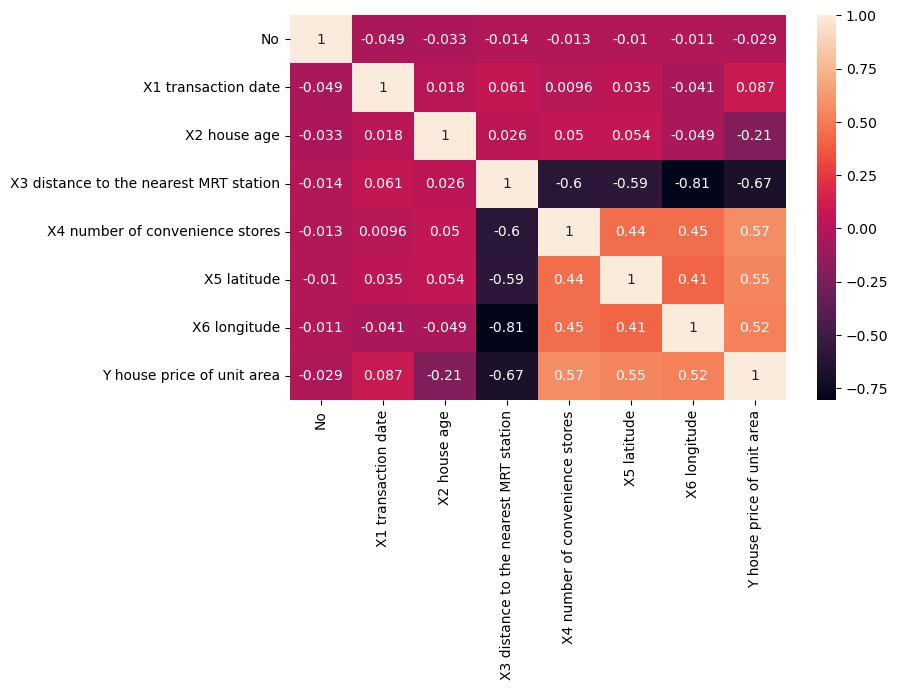

In [4]:
# Create a figure with width=8 inches and height=5 inches
plt.figure(figsize=(8,5))
sns.heatmap(cor,annot=True)


In [5]:
# Features (X) must always be 2-dimensional (DataFrame)
# Target (y) must always be 1-dimensional (Series)
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [6]:
feature=['X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target='Y house price of unit area'

In [7]:
X=df[feature]
Y=df[target]

split Data

In [8]:
'''
x->features
y->target
test_size->split test size
random_state=42(index)
random_state->data shuffle ,42th index extract data
'''

'\nx->features\ny->target\ntest_size->split test size\nrandom_state=42(index)\nrandom_state->data shuffle ,42th index extract data\n'

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [10]:
#(xi-mean)/sd

scaler = StandardScaler()



In [11]:
#fit_transform->feature training->fit(learning) transform(implement)
#transform(implementation)->features testing
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

Linear Regression Model

In [12]:
model=LinearRegression()

In [13]:
#training model
model.fit(X_train_scale,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# β0 = Intercept (constant)
beta_0 = model.intercept_

# β1 = Coefficient(s) or slope(s)
beta_1 = model.coef_

print(f'Intercept (β0): {beta_0}')
print(f'Slope/Coefficient(s) (β1): {beta_1}')


Intercept (β0): 38.39154078549814
Slope/Coefficient(s) (β1): [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]


In [15]:

# Testing / Prediction
# y = b0 + b1*x1 + b2*x2 + ... + bn*xn

Y_pred = model.predict(X_test_scale)

In [16]:
Y_pred

array([47.74180481, 41.95484652, 44.5399885 , 41.33697932, 30.28548   ,
       42.84474934, 45.98717123, 45.90599326, 24.78369465, 52.02068924,
       32.23880597, 34.77542016, 39.51392044, 24.90203898, 35.73984968,
       32.99552705, 41.96863217, 46.98662328, 31.50100311, 44.49258341,
        2.21362693, 33.64381059, 47.764103  , 43.56374399, 14.07301949,
       41.29883092, 14.73315281, 44.5399885 , 36.13972668, 37.76019401,
       11.66211419, 39.22848089, 37.83881729, 28.61334713, 45.93500741,
       31.52925298, 52.2101045 , 15.18188713, 46.84531477, 40.47464938,
       36.01694465, 40.58052131, 48.38869976, 39.8943259 , 42.00896517,
       48.22742934, 45.07252677, 23.5290158 , 49.9849698 , 48.13933326,
       47.74180481, 48.54209921, 40.94754085, 42.54642454, 36.38766353,
       15.15482781, 35.13348041, 36.39866246, 30.20430203, 45.90599326,
       33.69672647, 32.65567761, 15.15482781, 11.8739673 ,  8.74877596,
       33.67086991, 29.81801432, 45.24751413, 34.2425491 , 30.54

Metrics

In [17]:
# Mean Absolute Error (average absolute difference between actual and predicted values)
mae = mean_absolute_error(Y_test, Y_pred)

# Mean Squared Error (average of squared prediction errors)
mse = mean_squared_error(Y_test, Y_pred)

# Root Mean Squared Error (square root of MSE, in the same unit as the target)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

# R² Score (proportion of variance explained by the model)
r2 = r2_score(Y_test, Y_pred)

In [18]:
print(f'mean_absolute_error:{mae}')
print(f'mean_squared_error:{mse}')
print(f'rmse:{rmse}')
print(f'r2 score:{r2}')

mean_absolute_error:5.350138374356212
mean_squared_error:54.58094520086213
rmse:7.38789179677546
r2 score:0.6746481382828176


visualization

<Axes: xlabel='Y house price of unit area'>

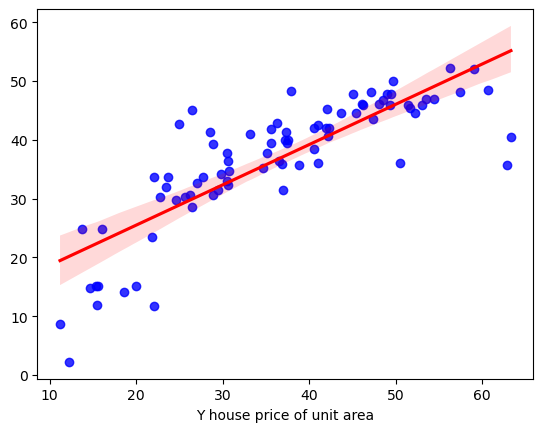

In [19]:
sns.regplot(
    x=Y_test,
    y=Y_pred,
    color='blue',
    line_kws={'color': 'red'}
)

In [20]:
min_val=min(Y_test.min(),Y_pred.min())
max_val=max(Y_test.max(),Y_pred.max())


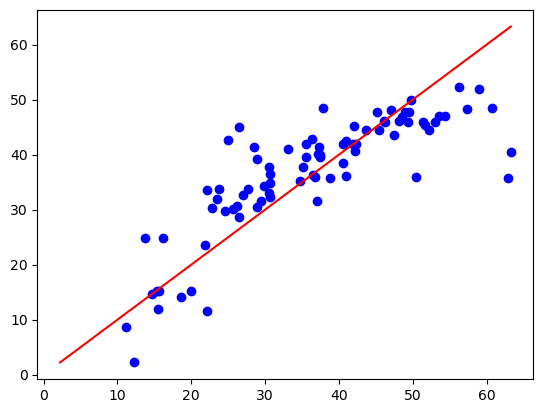

In [21]:
plt.scatter(Y_test,Y_pred,color='blue')
plt.plot([min_val,max_val],[min_val,max_val],color='red')

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Create a Random Forest Regressor with 100 decision trees
rf = RandomForestRegressor(n_estimators=100)

In [24]:
# Train the Random Forest Regressor using the scaled training data
rf.fit(X_train_scale, Y_train)

# Predict target values for the scaled test data
rf_pred = rf.predict(X_test_scale)

In [25]:
rf_pred

array([51.26796667, 36.59875   , 57.56676667, 34.097     , 25.928     ,
       39.51466667, 45.292     , 53.27582381, 14.698     , 60.0495    ,
       25.342     , 31.116     , 33.96475   , 15.114     , 37.581     ,
       25.282     , 39.56266667, 59.03133333, 25.6       , 36.28866667,
       17.927     , 23.333     , 49.881     , 46.14879167, 15.86152381,
       35.63      , 13.893     , 57.56676667, 54.541     , 36.8005    ,
       15.474     , 25.079     , 36.618     , 26.31516667, 49.71317143,
       37.162     , 53.267     , 14.797     , 38.8135    , 53.274     ,
       41.6075    , 43.476     , 46.68      , 38.8465    , 39.17858333,
       49.8869    , 36.3725    , 23.971     , 49.22033333, 46.327     ,
       51.26796667, 55.878     , 41.483     , 38.658     , 38.418     ,
       14.887     , 37.43126667, 26.84      , 25.847     , 53.27582381,
       29.538     , 24.586     , 14.887     , 16.891     , 17.853     ,
       23.428     , 27.85133333, 39.91933333, 38.218     , 26.55

In [26]:
# Calculate Root Mean Squared Error (RMSE)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))

# Calculate R-squared (R²) score
rf_r2 = r2_score(Y_test, rf_pred)             

In [27]:
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest RMSE: 6.019584545317863
Random Forest R² Score: 0.7840042126801414


<Axes: xlabel='Y house price of unit area'>

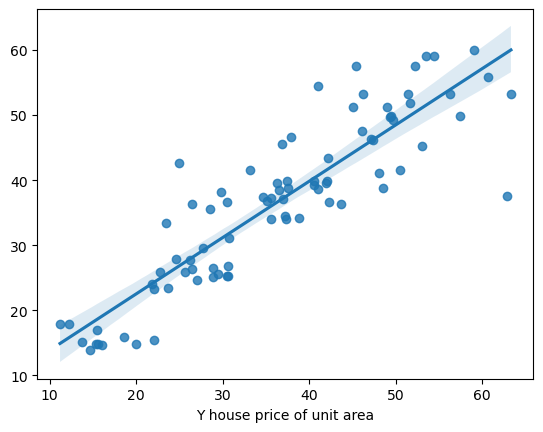

In [28]:
sns.regplot(x=Y_test,y=rf_pred)

In [29]:
data = {
    'X2 house age': [3, 2, 5],
    'X3 distance to the nearest MRT station': [287.6025, 84.87882, 323.655],
    'X4 number of convenience stores': [10, 3, 5],
    'X5 latitude': [24.99156, 24.97528, 24.98034],
    'X6 longitude': [121.48458, 121.51151, 121.54024]
}

In [30]:
test_df = pd.DataFrame(data)

test_scale = scaler.transform(test_df)

test_pred = model.predict(test_scale)      # Linear Regression prediction
test_rf_pred = rf.predict(test_scale)      # Random Forest prediction

test_df['Predicted Price'] = test_pred
test_df['RF_Predicted_Price'] = test_rf_pred

test_df

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Predicted Price,RF_Predicted_Price
0,3,287.60250,10,24.99156,121.48458,58.669161,71.691533
1,2,84.87882,3,24.97528,121.51151,47.639490,63.423824
2,5,323.65500,5,24.98034,121.54024,48.458800,49.102033
